# Apache Drill come Query Federation Engine

**Corso**: Big Data Analytics — Tutorial accademico
**Dataset**: HealthData.gov (U.S. Department of Health & Human Services), pandemia COVID-19

## Obiettivo

Dimostrare che Apache Drill puo' interrogare con **una singola query SQL** sorgenti eterogenee
**senza alcun ETL**: nessun dato viene copiato, trasformato o spostato prima della query.

## Le 3 sorgenti reali del progetto

Il progetto usa **3 storage plugin** di Drill, ciascuno verso un sistema diverso:

| Plugin | Cos'e' | Cosa contiene qui |
|---|---|---|
| **`dfs`** | *Distributed File System* — il plugin che da' accesso al file system locale (o HDFS/S3 in produzione). Non e' un database: e' semplicemente la porta di Drill sui file. | `covid/hospital_capacity.csv`, `covid_parquet/hospital_capacity.parquet`, `county/community_profile.csv`, `treatments/treatments_clean.csv` |
| **`pg`** | Connessione JDBC a **PostgreSQL** | tabella `estimated_beds` |
| **`mongo`** | Connessione nativa a **MongoDB** | collection `therapeutic` |

**Nota importante**: CSV e Parquet *non* sono due sorgenti diverse — sono due **formati file**
che vivono entrambi sotto il plugin `dfs`. Ha senso includere `dfs` nel notebook proprio perche'
e' la sorgente che ci permette di confrontare formati diversi (CSV vs Parquet, Query 5) a parita'
di dato. Le vere 3 sorgenti *eterogenee* che la Query 4 mette in join sono `dfs` + `pg` + `mongo`.

## Architettura

```
        Jupyter  --- REST API (query.json) --->  Apache Drill (:8047)
                                                        |
                         +------------------------------+------------------------------+
                         |                              |                              |
                    dfs (filesystem)               pg (JDBC)                    mongo (MongoDB)
                    CSV / Parquet                  PostgreSQL                   MongoDB
                    ./data/                        estimated_beds table         therapeutic collection
```

Drill applica lo **schema-on-read**: non serve definire uno schema prima di interrogare i dati,
lo inferisce al momento della query. Il query planner di Drill (basato su Apache Calcite) genera
un piano fisico che esegue scan/filtri sulle singole sorgenti e poi combina i risultati
(join, aggregazioni) in memoria nel cluster Drill.

## Stile del notebook

Procediamo in modo **incrementale**: prima una query per sorgente singola (Q1, Q2, Q3), poi
costruiamo il join federato **un passo alla volta** (Q4a → Q4f): prima le coppie di sorgenti,
poi tutte e 3 insieme, poi due varianti "intensive" a livello di riga per vedere come cambia il
costo quando si rinuncia alla pre-aggregazione. Infine il confronto CSV vs Parquet (Q5).

Le query girano via **REST API** (`http://drill:8047/query.json`, hostname Docker interno alla
rete `health-net`); ogni esecuzione viene cronometrata e accumulata in `timings` per il riepilogo
finale.

In [2]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

DRILL_REST = "http://drill:8047/query.json"

def drill_query(sql: str, label: str = None, group: str = None):
    """Esegue una query su Drill via REST API, misura il tempo e ritorna un DataFrame."""
    payload = {"queryType": "SQL", "query": sql}
    t0 = time.perf_counter()
    r = requests.post(DRILL_REST, json=payload, timeout=120)
    elapsed = time.perf_counter() - t0
    r.raise_for_status()
    data = r.json()
    if data.get("queryState") == "FAILED":
        raise RuntimeError(f"Query fallita: {data}")
    df = pd.DataFrame(data.get("rows", []), columns=data.get("columns", []))
    timings.append({"query": label or sql[:40], "group": group or "altro", "seconds": elapsed, "rows": len(df)})
    print(f"[{label}] {elapsed:.3f}s — {len(df)} righe")
    return df

timings = []  # accumula i tempi di tutte le query eseguite in questo notebook

# sanity check di connessione
drill_query("SELECT * FROM sys.version", label="sanity-check", group="setup")

[sanity-check] 0.220s — 1 righe


,version,commit_id,commit_message,commit_time,build_email,build_time
0,1.21.0,ff86c29b125776c56f361fc9187fb96458de37a6,[maven-release-plugin] prepare release drill-1...,15.02.2023 @ 05:29:23 UTC,None,None


## Query 1 — Schema-on-read su CSV grezzo (sorgente: `dfs`, Dataset 1)

Trend ospedalizzazioni COVID per stato e data, letto direttamente dal CSV grezzo scaricato da
healthdata.gov — nessuna tabella, nessuno schema dichiarato. Drill inferisce i tipi al volo.

Note sul dato grezzo:
- `inpatient_beds_used_covid` contiene virgole come separatore delle migliaia (es. `"1,338"`)
  e valori vuoti — puliti in query con `REPLACE` + `NULLIF` prima del `CAST`.
- Le righe con valore mancante diventano `NULL` dopo il cast: le escludiamo con un filtro
  esterno, altrimenti `ORDER BY ... DESC` le mostrerebbe per prime (Drill tratta `NULL` come
  "piu' grande di qualsiasi numero" in ordinamento decrescente di default).

In [3]:
q1 = """
SELECT state, `date`, covid_beds_used FROM (
  SELECT state,
         `date`,
         SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
  FROM dfs.healthdata.`covid/hospital_capacity.csv`
  WHERE `date` >= '2021/01/01'
  GROUP BY state, `date`
) t
WHERE covid_beds_used IS NOT NULL
ORDER BY covid_beds_used DESC
LIMIT 20
"""
df1 = drill_query(q1, label="Q1 dfs-csv", group="singola-sorgente")
df1

[Q1 dfs-csv] 1.140s — 20 righe


,state,date,covid_beds_used
0,CA,2021/01/14,30334
1,CA,2021/01/06,22872
2,CA,2021/01/07,22835
3,CA,2021/01/05,22715
4,CA,2021/01/10,22678
5,CA,2021/01/08,22636
6,CA,2021/01/11,22594
7,CA,2021/01/09,22564
8,CA,2021/01/12,22453
9,CA,2021/01/04,22445


## Query 2 — Aggregazioni su PostgreSQL (sorgente: `pg`, Dataset 2)

Occupazione stimata dei letti COVID per stato. Qui Drill si comporta da client JDBC: la query
viene tradotta e in parte spinta (pushdown) su PostgreSQL, che e' ottimizzato per aggregazioni
su dati relazionali strutturati.

In [5]:
q2 = """
SELECT state,
       COUNT(*)                              AS num_observations,
       ROUND(AVG(estimated_beds_covid), 0)   AS avg_estimated_beds_covid,
       ROUND(AVG(pct_beds_covid), 4)         AS avg_pct_covid
FROM pg.healthdata.estimated_beds
GROUP BY state
ORDER BY avg_estimated_beds_covid DESC
LIMIT 20
"""
df2 = drill_query(q2, label="Q2 pg", group="singola-sorgente")
df2

[Q2 pg] 0.364s — 20 righe


,state,num_observations,avg_estimated_beds_covid,avg_pct_covid
0,CW,31,24884.0,3.6145
1,FL,31,4254.0,8.2155
2,TX,31,3146.0,5.4910
3,CA,31,2137.0,3.6074
4,MO,31,1318.0,9.2265
5,GA,31,979.0,5.1148
6,NY,31,803.0,1.6984
7,NV,31,749.0,10.1061
8,OH,31,698.0,2.4335
9,AZ,31,673.0,4.8058


## Query 3 — Flessibilita' di schema su MongoDB (sorgente: `mongo`, Dataset 3)

Centri terapeutici attivi per stato e farmaco distribuito. MongoDB e' un document store: Drill
legge i documenti JSON-like della collection `therapeutic` e li tratta come righe SQL, senza che
esista uno schema relazionale dichiarato a monte.

In [6]:
q3 = """
SELECT t.state,
       t.order_label     AS therapy_name,
       COUNT(*)          AS num_centers
FROM mongo.healthdata.therapeutic t
WHERE t.provider_status = 'ACTIVE'
GROUP BY t.state, t.order_label
ORDER BY num_centers DESC
LIMIT 20
"""
df3 = drill_query(q3, label="Q3 mongo", group="singola-sorgente")
df3

[Q3 mongo] 0.244s — 20 righe


,state,therapy_name,num_centers
0,CA,Renal Paxlovid,1642
1,CA,Paxlovid,1512
2,TX,Renal Paxlovid,1072
3,CA,Lagevrio (molnupiravir),852
4,TX,Paxlovid,821
5,FL,Renal Paxlovid,777
6,PA,Renal Paxlovid,764
7,PA,Paxlovid,755
8,NY,Renal Paxlovid,740
9,NY,Paxlovid,651


## Query 4 — Costruire il JOIN federato un passo alla volta

Invece di saltare direttamente al join a 3 vie, lo costruiamo incrementalmente:

1. **Q4a** — `dfs` + `pg` (2 sorgenti, aggregate per stato)
2. **Q4b** — `dfs` + `mongo` (2 sorgenti, aggregate per stato)
3. **Q4c** — `pg` + `mongo` (2 sorgenti, aggregate per stato)
4. **Q4d** — `dfs` + `pg` + `mongo` (le 3 sorgenti insieme, aggregate per stato)
5. **Q4e** — `dfs` + `pg`, ma **a livello di riga** (join su `stato + data`, senza pre-aggregare
   le due serie storiche prima del join): confronto giorno per giorno letti-occupati-reali vs
   letti-stimati
6. **Q4f** — Q4e arricchita con `mongo` (le 3 sorgenti, join piu' pesante: due serie storiche a
   livello di riga + una dimensione aggregata)

In tutti i casi Drill esegue gli scan sulle singole sorgenti (con le eventuali sub-aggregazioni
spinte il piu' vicino possibile ai dati) e poi fa il join in memoria nel cluster. **Nessun dato
viene copiato o pre-caricato altrove.**

### Q4a — `dfs` + `pg` (2 vie, per stato)

In [9]:
q4a = """
SELECT h.state, h.covid_beds_used, e.avg_estimated_beds_covid
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) h
JOIN (
    SELECT state,
           ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
) e ON h.state = e.state
ORDER BY h.covid_beds_used DESC
"""
df4a = drill_query(q4a, label="Q4a dfs+pg", group="join-2-vie")
print(f"Q4a: dfs+pg length = {len(df4a)} ")
df4a.head(10)


[Q4a dfs+pg] 1.334s — 51 righe
Q4a: dfs+pg length = 51 


,state,covid_beds_used,avg_estimated_beds_covid
0,FL,2868,4254.0
1,TX,2377,3146.0
2,CA,1670,2137.0
3,MO,1250,1318.0
4,NY,743,803.0
5,GA,726,979.0
6,NV,659,749.0
7,AZ,563,673.0
8,OH,551,698.0
9,AR,523,623.0


### Q4b — `dfs` + `mongo` (2 vie, per stato)

In [10]:
q4b = """
SELECT h.state, h.covid_beds_used, c.num_therapy_centers
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) h
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON h.state = c.state
ORDER BY h.covid_beds_used DESC
"""
df4b = drill_query(q4b, label="Q4b dfs+mongo", group="join-2-vie")
print(f"Q4b: dfs+mongo length = {len(df4b)} ")
df4b.head(10)

[Q4b dfs+mongo] 1.175s — 52 righe
Q4b: dfs+mongo length = 52 


,state,covid_beds_used,num_therapy_centers
0,FL,2868,1884
1,TX,2377,2481
2,CA,1670,4007
3,MO,1250,510
4,NY,743,1796
5,GA,726,784
6,NV,659,278
7,AZ,563,620
8,OH,551,1198
9,AR,523,61


### Q4c — `pg` + `mongo` (2 vie, per stato)

In [11]:
q4c = """
SELECT e.state, e.avg_estimated_beds_covid, c.num_therapy_centers
FROM (
    SELECT state,
           ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
) e
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON e.state = c.state
ORDER BY e.avg_estimated_beds_covid DESC
"""
df4c = drill_query(q4c, label="Q4c pg+mongo", group="join-2-vie")
print(f"Q4c: pg+mongo length = {len(df4c)} ")
df4c.head(10)

[Q4c pg+mongo] 1.779s — 51 righe
Q4c: pg+mongo length = 51 


,state,avg_estimated_beds_covid,num_therapy_centers
0,FL,4254.0,1884
1,TX,3146.0,2481
2,CA,2137.0,4007
3,MO,1318.0,510
4,GA,979.0,784
5,NY,803.0,1796
6,NV,749.0,278
7,OH,698.0,1198
8,AZ,673.0,620
9,AR,623.0,61


### Q4d — `dfs` + `pg` + `mongo` (3 vie, per stato — il join federato "leggero")

In [12]:
q4d = """
SELECT
    h.state,
    h.covid_beds_used,
    e.avg_estimated_beds_covid,
    c.num_therapy_centers
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) h
JOIN (
    SELECT state,
           ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
) e ON h.state = e.state
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON h.state = c.state
ORDER BY h.covid_beds_used DESC
"""
df4d = drill_query(q4d, label="Q4d dfs+pg+mongo", group="join-3-vie")
print(f"Q4d: dfs+pg+mongo length = {len(df4d)} ")
df4d.head(15)

[Q4d dfs+pg+mongo] 1.889s — 51 righe
Q4d: dfs+pg+mongo length = 51 


,state,covid_beds_used,avg_estimated_beds_covid,num_therapy_centers
0,FL,2868,4254.0,1884
1,TX,2377,3146.0,2481
2,CA,1670,2137.0,4007
3,MO,1250,1318.0,510
4,NY,743,803.0,1796
5,GA,726,979.0,784
6,NV,659,749.0,278
7,AZ,563,673.0,620
8,OH,551,698.0,1198
9,AR,523,623.0,61


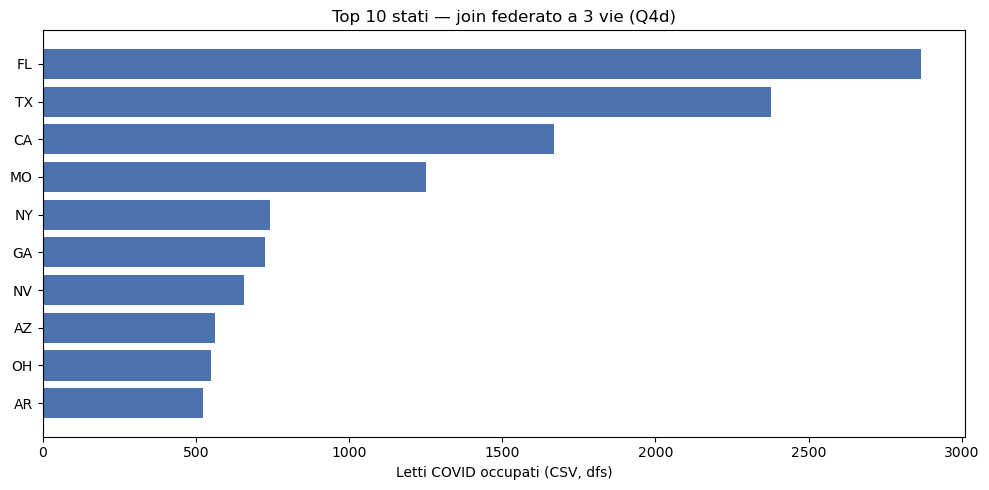

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
top = df4d.head(10).sort_values("covid_beds_used")
ax.barh(top["state"], top["covid_beds_used"], color="#4C72B0")
ax.set_xlabel("Letti COVID occupati (CSV, dfs)")
ax.set_title("Top 10 stati — join federato a 3 vie (Q4d)")
plt.tight_layout()
plt.show()

### Q4e — `dfs` + `pg`, join intensivo a livello di riga

Le query precedenti pre-aggregano ogni sorgente per stato *prima* del join (poche righe da
unire). Qui invece uniamo le due serie storiche **riga per riga**, sulla chiave composta
`stato + data`, senza aggregare prima: confrontiamo il dato ospedaliero reale (CSV) con la stima
(PostgreSQL) giorno per giorno, per ogni stato, nella finestra temporale in cui le due sorgenti si
sovrappongono (fine giugno – fine luglio 2021).

Nota tecnica: `dfs` rappresenta la data come stringa `"yyyy/MM/dd"`, mentre `pg` la rappresenta
come `DATE` nativo — serve convertire con `TO_DATE` prima di poterle confrontare nel join.

In [13]:
q4e = """
SELECT h.state, h.`date`,
       CAST(NULLIF(REPLACE(h.inpatient_beds_used_covid, ',', ''), '') AS BIGINT) AS covid_beds_used,
       e.estimated_beds_covid
FROM dfs.healthdata.`covid/hospital_capacity.csv` h
JOIN pg.healthdata.estimated_beds e
  ON h.state = e.state
 AND TO_DATE(h.`date`, 'yyyy/MM/dd') = e.collection_date
ORDER BY h.state, h.`date`
"""
df4e = drill_query(q4e, label="Q4e dfs+pg row-level", group="join-intensivo")
df4e.head(10)

[Q4e dfs+pg row-level] 2.684s — 1581 righe


,state,date,covid_beds_used,estimated_beds_covid
0,AK,2021/06/28,15,15.0
1,AK,2021/06/29,14,14.0
2,AK,2021/06/30,18,17.0
3,AK,2021/07/01,19,18.0
4,AK,2021/07/02,23,22.0
5,AK,2021/07/03,22,21.0
6,AK,2021/07/04,24,23.0
7,AK,2021/07/05,27,27.0
8,AK,2021/07/06,21,21.0
9,AK,2021/07/07,30,29.0


### Q4f — `dfs` + `pg` + `mongo`, join intensivo a 3 vie

La versione piu' pesante della demo: il join riga-per-riga di Q4e (due serie storiche, chiave
`stato + data`) arricchito con il conteggio dei centri terapeutici attivi per stato (`mongo`,
aggregato). E' l'unione dei due stili — join a grana fine su due sorgenti, join a grana grossa
sulla terza — che si puo' incontrare in una vera pipeline analitica.

In [14]:
q4f = """
SELECT hp.state, hp.`date`, hp.covid_beds_used, hp.estimated_beds_covid, c.num_therapy_centers
FROM (
    SELECT h.state, h.`date`,
           CAST(NULLIF(REPLACE(h.inpatient_beds_used_covid, ',', ''), '') AS BIGINT) AS covid_beds_used,
           e.estimated_beds_covid
    FROM dfs.healthdata.`covid/hospital_capacity.csv` h
    JOIN pg.healthdata.estimated_beds e
      ON h.state = e.state
     AND TO_DATE(h.`date`, 'yyyy/MM/dd') = e.collection_date
) hp
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON hp.state = c.state
ORDER BY hp.state, hp.`date`
"""
df4f = drill_query(q4f, label="Q4f dfs+pg+mongo row-level", group="join-intensivo")
df4f.head(10)

[Q4f dfs+pg+mongo row-level] 2.700s — 1581 righe


,state,date,covid_beds_used,estimated_beds_covid,num_therapy_centers
0,AK,2021/06/28,15,15.0,49
1,AK,2021/06/29,14,14.0,49
2,AK,2021/06/30,18,17.0,49
3,AK,2021/07/01,19,18.0,49
4,AK,2021/07/02,23,22.0,49
5,AK,2021/07/03,22,21.0,49
6,AK,2021/07/04,24,23.0,49
7,AK,2021/07/05,27,27.0,49
8,AK,2021/07/06,21,21.0,49
9,AK,2021/07/07,30,29.0,49


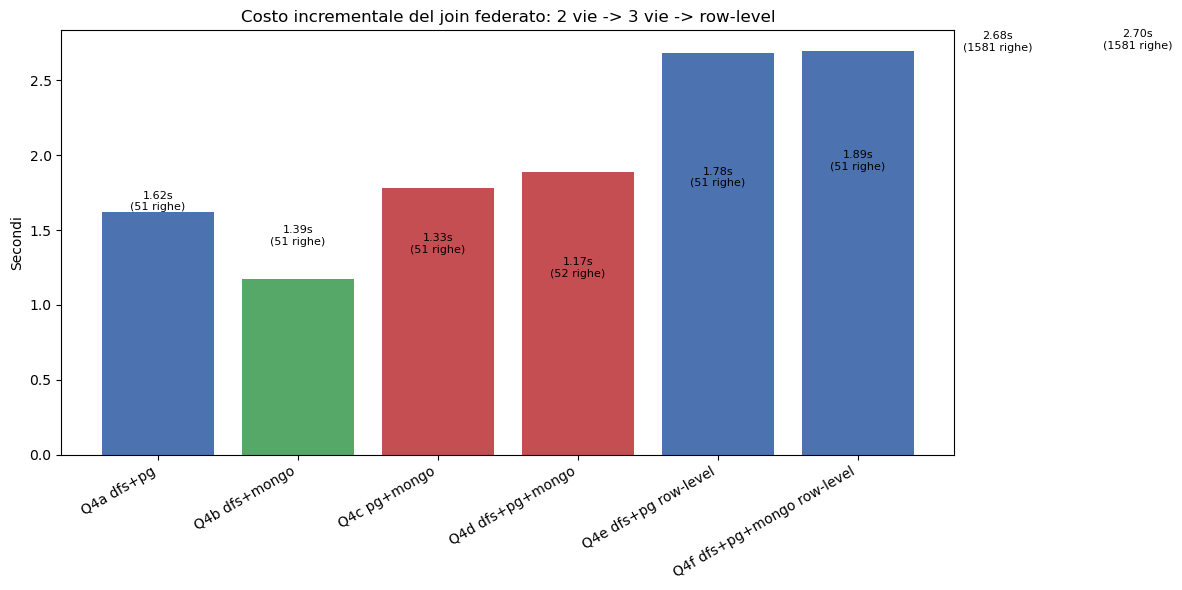

In [15]:
# Confronto incrementale: tempo di esecuzione al crescere della complessita' del join
join_steps = ["Q4a dfs+pg", "Q4b dfs+mongo", "Q4c pg+mongo", "Q4d dfs+pg+mongo",
              "Q4e dfs+pg row-level", "Q4f dfs+pg+mongo row-level"]
df_join_steps = pd.DataFrame(timings)
df_join_steps = df_join_steps[df_join_steps["query"].isin(join_steps)].set_index("query").loc[join_steps]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C72B0"] * 3 + ["#55A868"] + ["#C44E52"] * 2
ax.bar(df_join_steps.index, df_join_steps["seconds"], color=colors)
ax.set_ylabel("Secondi")
ax.set_title("Costo incrementale del join federato: 2 vie -> 3 vie -> row-level")
for i, (v, r) in enumerate(zip(df_join_steps["seconds"], df_join_steps["rows"])):
    ax.text(i, v, f"{v:.2f}s\n({r} righe)", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Query 5 — CSV vs Parquet: piano di esecuzione e tempi reali

Stesso dataset (Dataset 1), stesso plugin (`dfs`), due formati:
- **CSV**: row store testuale, letto e parsato riga per riga
- **Parquet**: columnar store binario compresso, con statistiche per colonna

Prima guardiamo il piano fisico generato da Drill (`EXPLAIN PLAN FOR`), poi eseguiamo davvero
entrambe le query e confrontiamo i tempi.

In [13]:
explain_csv = """
EXPLAIN PLAN FOR
SELECT state, SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT))
FROM dfs.healthdata.`covid/hospital_capacity.csv`
GROUP BY state
"""
explain_parquet = """
EXPLAIN PLAN FOR
SELECT state, SUM(inpatient_beds_used_covid)
FROM dfs.healthdata.`covid_parquet/hospital_capacity.parquet`
GROUP BY state
"""

plan_csv = drill_query(explain_csv, label="explain-csv", group="csv-vs-parquet")
plan_parquet = drill_query(explain_parquet, label="explain-parquet", group="csv-vs-parquet")

print("\n--- Piano CSV (estratto) ---")
print(plan_csv.iloc[0, 0][:600])
print("\n--- Piano Parquet (estratto) ---")
print(plan_parquet.iloc[0, 0][:600])

[explain-csv] 0.214s — 1 righe
[explain-parquet] 0.184s — 1 righe

--- Piano CSV (estratto) ---
00-00    Screen
00-01      Project(state=[$0], EXPR$1=[$1])
00-02        HashAgg(group=[{0}], EXPR$1=[SUM($1)])
00-03          HashAgg(group=[{0}], EXPR$1=[SUM($1)])
00-04            Project(state=[$0], $f1=[CAST(CASE(=(REPLACE($1, ',', ''), ''), null:NULL, REPLACE($1, ',', ''))):BIGINT])
00-05              Scan(table=[[dfs, healthdata, covid/hospital_capacity.csv]], groupscan=[EasyGroupScan [selectionRoot=file:/data/healthdata/covid/hospital_capacity.csv, numFiles=1, columns=[`state`, `inpatient_beds_used_covid`], files=[file:/data/healthdata/covid/hospital_capacity.csv], usedMetastore=false,

--- Piano Parquet (estratto) ---
00-00    Screen
00-01      Project(state=[$0], EXPR$1=[$1])
00-02        HashAgg(group=[{0}], EXPR$1=[SUM($1)])
00-03          Scan(table=[[dfs, healthdata, covid_parquet/hospital_capacity.parquet]], groupscan=[ParquetGroupScan [entries=[ReadEntryWithPath [path=file:/d

In [14]:
# Esecuzione reale (non solo EXPLAIN) per confrontare i tempi effettivi
select_csv = """
SELECT state, SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS n
FROM dfs.healthdata.`covid/hospital_capacity.csv`
GROUP BY state
"""
select_parquet = """
SELECT state, SUM(inpatient_beds_used_covid) AS n
FROM dfs.healthdata.`covid_parquet/hospital_capacity.parquet`
GROUP BY state
"""

N_RUNS = 3  # media su piu' run per ridurre rumore
csv_times, parquet_times = [], []
for i in range(N_RUNS):
    _ = drill_query(select_csv, label=f"csv-run-{i+1}", group="csv-vs-parquet")
    csv_times.append(timings[-1]["seconds"])
    _ = drill_query(select_parquet, label=f"parquet-run-{i+1}", group="csv-vs-parquet")
    parquet_times.append(timings[-1]["seconds"])

avg_csv = sum(csv_times) / len(csv_times)
avg_parquet = sum(parquet_times) / len(parquet_times)
print(f"\nMedia CSV:     {avg_csv:.3f}s")
print(f"Media Parquet: {avg_parquet:.3f}s")
print(f"Speedup: {avg_csv / avg_parquet:.2f}x")

[csv-run-1] 0.767s — 54 righe
[parquet-run-1] 0.214s — 54 righe
[csv-run-2] 0.775s — 54 righe
[parquet-run-2] 0.277s — 54 righe
[csv-run-3] 0.959s — 54 righe
[parquet-run-3] 0.439s — 54 righe

Media CSV:     0.833s
Media Parquet: 0.310s
Speedup: 2.69x


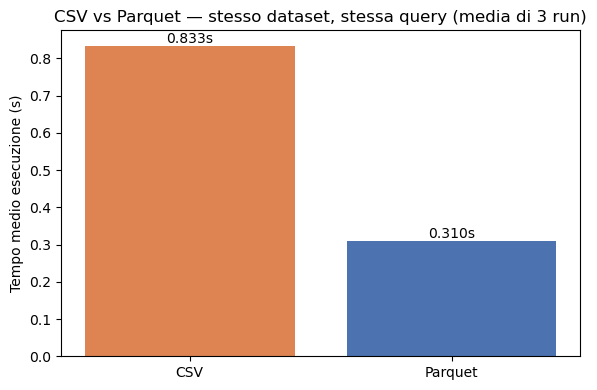

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["CSV", "Parquet"], [avg_csv, avg_parquet], color=["#DD8452", "#4C72B0"])
ax.set_ylabel("Tempo medio esecuzione (s)")
ax.set_title(f"CSV vs Parquet — stesso dataset, stessa query (media di {N_RUNS} run)")
for i, v in enumerate([avg_csv, avg_parquet]):
    ax.text(i, v, f"{v:.3f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Query 6 — Multi-scala: stato + contea sullo stesso plugin `dfs` (Dataset 1 + 4)

Due CSV diversi, granularita' diverse (stato vs contea), stesso storage plugin `dfs`.
Dimostra che la federazione di Drill funziona anche *tra file diversi della stessa sorgente*.

In [16]:
q6 = """
SELECT s.state,
       s.covid_beds_used   AS state_covid_beds,
       c.county,
       c.cases_last_7_days AS county_cases_7d
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) s
JOIN dfs.healthdata.`county/community_profile.csv` c
  ON s.state = c.state
ORDER BY state_covid_beds DESC, county_cases_7d DESC
LIMIT 30
"""
df6 = drill_query(q6, label="Q6 dfs-multi-scale", group="altro")
df6

[Q6 dfs-multi-scale] 0.874s — 30 righe


,state,state_covid_beds,county,county_cases_7d
0,FL,2868,"Volusia County, FL",99
1,FL,2868,"St. Lucie County, FL",90
2,FL,2868,"Wakulla County, FL",9
3,FL,2868,"Osceola County, FL",87
4,FL,2868,"Martin County, FL",85
5,FL,2868,"Collier County, FL",83
6,FL,2868,"Leon County, FL",82
7,FL,2868,"Marion County, FL",82
8,FL,2868,"Putnam County, FL",8
9,FL,2868,"Suwannee County, FL",8


## Query 7 — Disponibilita' terapie per sede (sorgente: `dfs`, Dataset 5)

Dataset complementare: quante sedi per stato offrono Paxlovid, Lagevrio, Veklury.

In [17]:
q7 = """
SELECT state,
       SUM(CASE WHEN has_paxlovid = 'true' THEN 1 ELSE 0 END) AS sites_with_paxlovid,
       SUM(CASE WHEN has_lagevrio = 'true' THEN 1 ELSE 0 END) AS sites_with_lagevrio,
       SUM(CASE WHEN has_veklury  = 'true' THEN 1 ELSE 0 END) AS sites_with_veklury,
       COUNT(*)                                                AS total_sites
FROM dfs.healthdata.`treatments/treatments_clean.csv`
GROUP BY state
ORDER BY total_sites DESC
LIMIT 20
"""
df7 = drill_query(q7, label="Q7 dfs-treatments", group="altro")
df7

[Q7 dfs-treatments] 0.491s — 20 righe


,state,sites_with_paxlovid,sites_with_lagevrio,sites_with_veklury,total_sites
0,CA,1501,949,0,6091
1,TX,1107,1042,0,5117
2,NY,825,573,2,4917
3,FL,813,719,2,4562
4,PA,927,471,0,2799
5,GA,329,299,0,2201
6,MI,267,176,1,2180
7,NJ,437,334,0,2139
8,OH,360,300,1,2107
9,NC,379,349,3,2084


## Riepilogo: tempi di esecuzione, raggruppati per tipo

Tutte le query eseguite in questo notebook, con i relativi tempi via REST API, raggruppate per
categoria (singola sorgente, join a 2 vie, join a 3 vie, join intensivo, CSV vs Parquet). Utile
per discutere in aula quali fattori influenzano la latenza in un motore federato: numero di
sorgenti coinvolte, pre-aggregazione vs join a livello di riga, formato dati (CSV vs Parquet).

In [18]:
df_timings = pd.DataFrame(timings)
df_timings

,query,group,seconds,rows
0,sanity-check,setup,0.263914,1
1,Q1 dfs-csv,singola-sorgente,1.249524,20
2,Q2 pg,singola-sorgente,0.444611,10
3,Q3 mongo,singola-sorgente,0.185842,20
4,Q4a dfs+pg,join-2-vie,1.121085,51
5,Q4b dfs+mongo,join-2-vie,0.911107,52
6,Q4c pg+mongo,join-2-vie,0.869087,51
7,Q4d dfs+pg+mongo,join-3-vie,1.618151,51
8,Q4e dfs+pg row-level,join-intensivo,3.249989,1581
9,Q4f dfs+pg+mongo row-level,join-intensivo,2.661136,1581


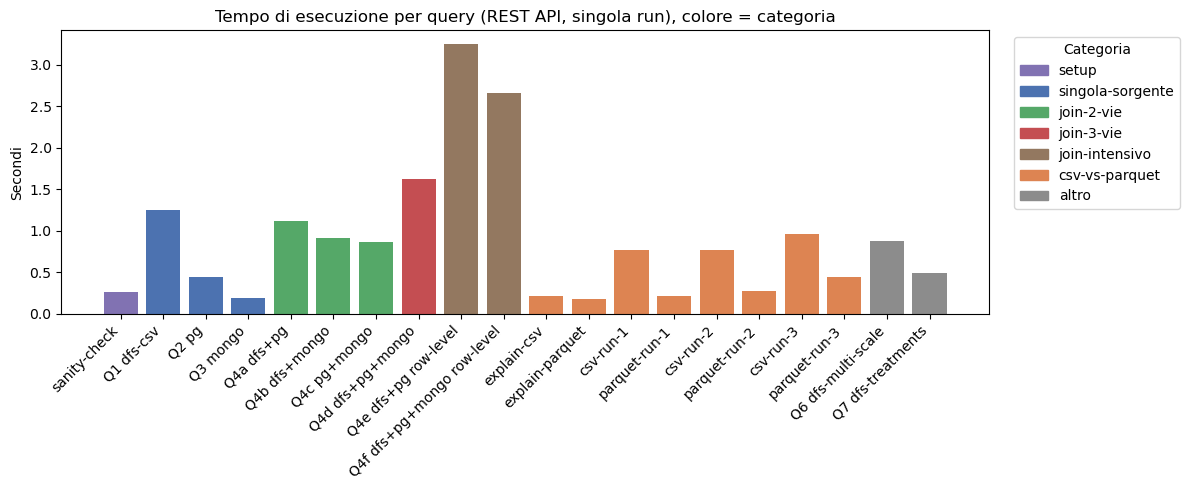

In [19]:
group_colors = {
    "setup": "#8172B2",
    "singola-sorgente": "#4C72B0",
    "join-2-vie": "#55A868",
    "join-3-vie": "#C44E52",
    "join-intensivo": "#937860",
    "csv-vs-parquet": "#DD8452",
    "altro": "#8C8C8C",
}
colors = df_timings["group"].map(group_colors)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_timings["query"], df_timings["seconds"], color=colors)
ax.set_ylabel("Secondi")
ax.set_title("Tempo di esecuzione per query (REST API, singola run), colore = categoria")
plt.xticks(rotation=45, ha="right")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Conclusioni

- Drill ha eseguito query dirette su CSV grezzo, PostgreSQL e MongoDB **senza alcuna fase di ETL**,
  usando un singolo endpoint SQL/REST.
- La costruzione incrementale del **join federato** (Q4a → Q4f) mostra che il costo cresce sia
  con il numero di sorgenti coinvolte (2 vie → 3 vie) sia, in modo piu' marcato, quando si passa
  da un join su dati pre-aggregati per stato a un join **a livello di riga** su chiave composta
  (stato + data): meno lavoro viene fatto vicino ai dati, piu' lavoro deve farlo Drill in memoria.
- Il confronto **CSV vs Parquet** (Q5) mostra concretamente il vantaggio del formato columnar:
  meno I/O, meno CPU per il parsing (niente `REPLACE`/`CAST` da fare a runtime), query piu' veloci
  a parita' di risultato.
- Lo **schema-on-read** permette di interrogare dati "sporchi" (virgole nei numeri, valori vuoti)
  senza doverli prima pulire e caricare altrove — la pulizia avviene nella query stessa, come
  visto nel piano di esecuzione della Query 5 (lo step `Project` con `CAST`/`REPLACE` presente
  solo nella versione CSV).